In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset and inspect class distribution (positive/negative/neutral counts)


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\kd940\OneDrive\Documents\yelp_dataset_reviews.csv")

In [4]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [5]:
df.tail()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
49995,49995,V_bNx4GEH8ChNNA0GPMrOA,_-x9v81zddshIEwRirV7kQ,GBTPC53ZrG1ZBY3DT8Mbcw,4,0,0,0,Came here first for breakfast and had their yu...,2016-10-29 00:54:49
49996,49996,5beIdB00qToFzllb4alZNQ,VEOTasfs8zYs7grZ4C5Xfw,EQ-TZ2eeD_E0BHuvoaeG5Q,2,0,0,0,Food was good. I had a decent breakfast but no...,2017-08-09 13:12:33
49997,49997,rjFWnq1zQTRzCyqV0jzZHw,AT_p7NkLqd50ugp3wjFg2Q,_RFqyBgklIBqOAM-zzV_WQ,3,0,1,0,It's cool that Second Image is trying. They so...,2010-07-11 21:41:35
49998,49998,8LRFPHiso_kuCseg5BJx8A,NSCNU_j0vSdeRMIme3H0rg,8agPzX-O-8LEDjDNloSdzQ,4,1,0,1,"Best shrimp on the beach! Steamed to order, d...",2017-04-09 23:23:56
49999,49999,5C6u-caMG39RkvDuAYSVew,TnLZ2QkrO9WpzDLLORvJtQ,M0c99tzIJPIbrY_RAO7KSQ,4,0,0,0,"The hotel is very nice and clean, and looks fa...",2016-08-06 02:17:10


In [6]:
df.shape

(50000, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   50000 non-null  int64
 1   review_id    50000 non-null  str  
 2   user_id      50000 non-null  str  
 3   business_id  50000 non-null  str  
 4   stars        50000 non-null  int64
 5   useful       50000 non-null  int64
 6   funny        50000 non-null  int64
 7   cool         50000 non-null  int64
 8   text         50000 non-null  str  
 9   date         50000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 34.0 MB


In [8]:
df.isna().sum()

Unnamed: 0     0
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

In [9]:
df['stars'].unique()

array([3, 5, 4, 1, 2])

# Text preprocessing pipeline: lowercase, punctuation removal, stopword removal, tokenisation, optional stemming/lemmatization

In [10]:
df["sentiment"] = df["stars"].map({
    1: "Negative",
    2: "Negative",
    3: "Neutral",
    4: "Positive",
    5: "Positive"
})

In [11]:
sentiment_count=df['sentiment'].value_counts()
sentiment_count

sentiment
Positive    34941
Negative     9382
Neutral      5677
Name: count, dtype: int64

Text(0, 0.5, 'Number of Reviews')

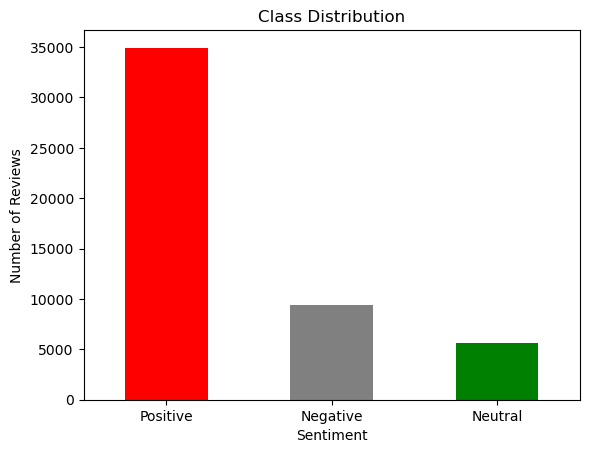

In [12]:
plt.Figure(figsize=(8,5))
sentiment_count.plot(kind='bar',color=["red","gray","green"])
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.ylabel("Number of Reviews")

### Interpretation: 
#### 1.Postive reviews are the majority class.
#### 2.Neutral reviews are the minority class.
#### 3.Negative reviews are the fewer.
#### 4.The dataset is imbalanced, Which explains why the Neutral Class is harder to learn for model 

The class distribution indicates that the Yelp dataset is dominated by positive reviews, followed by negative and neutral reviews. This class imbalance is common in customer review datasets because satisfied customers are more likely to leave high ratings. But during Model Devolopment we need to use resample, stratified train-test split, weighting technique because of  imbalanced class and to prevent bias result.

In [13]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date,sentiment
0,0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral
1,1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive
2,2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral
3,3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive
4,4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive


In [14]:
! pip install nltk
! pip install contractions

In [15]:
import re
import string
import contractions
import nltk

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [17]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kd940\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
stop_words = set(stopwords.words('english'))
print(stop_words)
stop_words = stop_words - {"not", "no", "nor","won't","hasn't","hadn't","haven't","doesn't","didn","isn't","aren't"}
lemmatizer = WordNetLemmatizer()

{'you', 'just', 'again', 'wasn', 'at', 'ma', 'on', 'during', 'whom', 'won', "wouldn't", "aren't", "they'd", 'they', "he's", 'of', 'for', 'their', 'isn', 'she', 'there', "shouldn't", 'aren', 'ours', 'can', 'me', 'wouldn', 'with', 'yours', "mightn't", 'now', 'once', 'between', 'out', "it'd", 'nor', 'yourself', 'after', 'him', 'should', 'both', 'while', 'were', 'very', 'until', "i'll", 'hadn', 'if', 'up', 'haven', 'most', 'will', 'o', 'before', "you're", 'too', 'we', 'ain', "i'm", "didn't", "shan't", 'over', 's', "they've", 'these', 'be', 'only', 'being', 'doing', "they'll", 'to', "should've", 'when', 'this', 'off', 'themselves', 'own', "mustn't", 'had', 'no', 'myself', "she'd", "hadn't", 'has', 'above', 'don', 'theirs', "he'd", 'by', "i'd", 'below', "she's", 'all', 'not', 'hasn', "won't", 'was', 'have', 'shan', 'hers', 'herself', 'that', 'few', 'yourselves', 're', 'here', 'or', "we'll", 'which', 'but', 'further', 'more', 'am', 've', "you'll", 'needn', "you've", 'i', 'from', 'y', "doesn't

In [19]:
def preprocess_text(text):
    text = text.lower()
    text=contractions.fix(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if len(word)>2]
    tokens = [word for word in tokens if not re.fullmatch(r'(.)\1{2,}', word)]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

In [20]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [21]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date,sentiment,clean_text
0,0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral,decide eat aware going take hour beginning end...
1,1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive,taken lot spin class year nothing compare clas...
2,2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral,family diner buffet eclectic assortment large ...
3,3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive,wow yummy different delicious favorite lamb cu...
4,4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive,cute interior owner gave tour upcoming patioro...


# Feature extraction: TF-IDF Vectorizer


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.8,
    max_features=20000,
    ngram_range=(1,2),
    token_pattern=r"\b[a-zA-Z]{3,}\b"
)

# Feature Extraction using TF-IDF Vectorizer

Machine learning algorithms cannot process raw text directly. Therefore, textual data must be transformed into numerical feature vectors before training a model. One of the most widely used techniques for this purpose is Term Frequency–Inverse Document Frequency (TF-IDF).

TF-IDF measures the importance of a word in a document relative to an entire collection of documents (corpus). Unlike simple word counts, TF-IDF assigns higher weights to words that are frequent in a specific review but uncommon across all reviews, making them more informative for sentiment classification.

For example, common words such as "the", "is", and "and" appear in almost every review, so they receive very low TF-IDF scores. On the other hand, words such as "excellent", "terrible", "delicious", and "awful" are more useful in distinguishing positive and negative reviews, so they receive higher scores.

Using TF-IDF reduces the influence of frequently occurring but less meaningful words while emphasizing words that contribute most to identifying sentiment. The resulting numerical feature matrix can then be used to train machine learning models such as Logistic Regression, Naïve Bayes, Support Vector Machines (SVM), and Random Forest.

In [24]:
x=tfidf.fit_transform(df['clean_text'])

In [25]:
y=df['sentiment']

In [26]:
x.shape

(50000, 20000)

# Train/test split (80/20

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Train at least 2 classifiers: Naive Bayes + one of (SVM, Logistic Regression, or a simple LSTM if comfortable with deep learning)

# Linear Support Vector Classifier

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.01, 0.1, 1, 5, 10]
}

grid = GridSearchCV(
    estimator=LinearSVC(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid.fit(x_train,y_train)

,estimator,LinearSVC(cla...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [30]:
print("Best C:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best C: {'C': 0.1}
Best CV Score: 0.6945633305621629


In [31]:
best_svm = grid.best_estimator_

In [32]:
y_pred = best_svm.predict(x_test)

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

In [34]:
svm_cm=confusion_matrix(y_test,y_pred)
svm_cm

array([[1511,  184,  182],
       [ 278,  413,  444],
       [ 165,  324, 6499]])

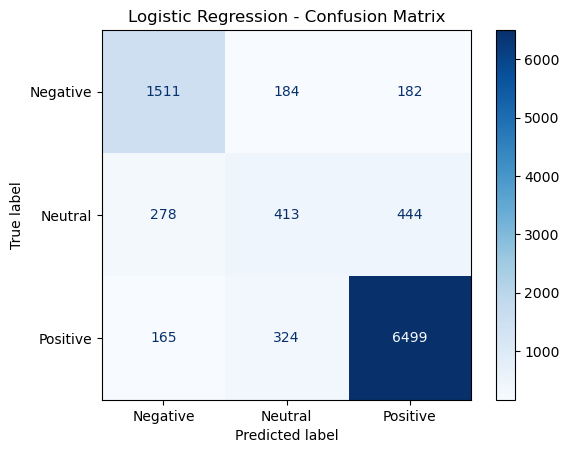

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_svm,x_test,y_test,cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [36]:
svm_accuracy=accuracy_score(y_test,y_pred)
print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8423


In [37]:
svm_pre=precision_score(y_test,y_pred,average='macro')
print(f"svm precision: {svm_pre:.4f}")

svm precision: 0.7113


In [38]:
svm_rec=recall_score(y_test,y_pred,average='macro')
print(f"svm recall: {svm_rec:.2f}")

svm recall: 0.70


In [39]:
svm_f1_score=f1_score(y_test,y_pred,average='macro')
print(f"SVM f1_score: {svm_f1_score:.4f}")

SVM f1_score: 0.7039


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.77      0.81      0.79      1877
     Neutral       0.45      0.36      0.40      1135
    Positive       0.91      0.93      0.92      6988

    accuracy                           0.84     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.83      0.84      0.84     10000



# Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)

In [43]:
lr_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
y_pred = lr_model.predict(x_test)

In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

In [46]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1451,   97,  329],
       [ 242,  208,  685],
       [  91,  105, 6792]])

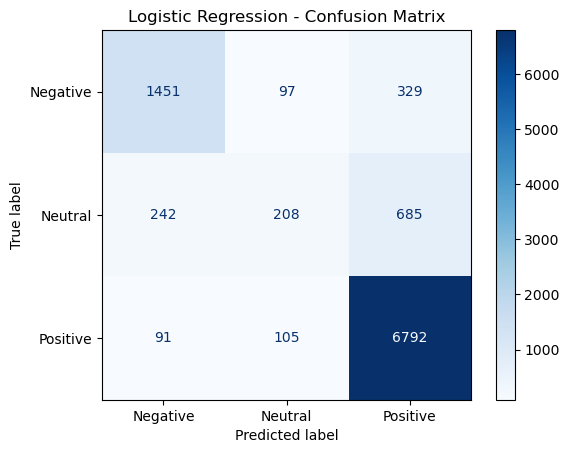

In [47]:

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(lr_model,x_test,y_test,cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [48]:
LR_Accuracy=accuracy_score(y_test,y_pred)
print(f"Logistic Regression Accuracy: {LR_Accuracy:.4f}")

Logistic Regression Accuracy: 0.8451


In [49]:
LR_pre=precision_score(y_test,y_pred,average='macro')
print(f"Logistic Regression Precision: {LR_pre:.4f}")

Logistic Regression Precision: 0.7303


In [50]:
LR_rec=recall_score(y_test,y_pred,average='macro')
print(f"Logistic Regression Recall: {LR_rec:.4f}")

Logistic Regression Recall: 0.6428


In [51]:
LR_f1_score=f1_score(y_test,y_pred,average='macro')
print(f"Logistic Regression f1_score: {LR_f1_score:.4f}")

Logistic Regression f1_score: 0.6600


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79      1877
     Neutral       0.51      0.18      0.27      1135
    Positive       0.87      0.97      0.92      6988

    accuracy                           0.85     10000
   macro avg       0.73      0.64      0.66     10000
weighted avg       0.82      0.85      0.82     10000



# Multinomial Naive Bayes

In [53]:
from sklearn.naive_bayes import MultinomialNB

In [54]:
nb_model=MultinomialNB(alpha=1.0)

In [55]:
nb_model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [56]:
nb_y_pred=nb_model.predict(x_test)

In [57]:
nb_cm=confusion_matrix(y_test,nb_y_pred)
nb_cm

array([[1176,    1,  700],
       [ 175,    3,  957],
       [  88,    0, 6900]])

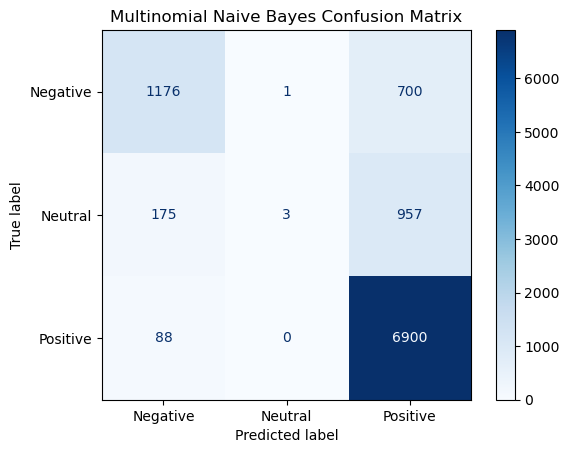

In [58]:
ConfusionMatrixDisplay.from_estimator(nb_model,x_test,y_test,cmap="Blues")
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

In [59]:
nb_accuracy=accuracy_score(y_test,nb_y_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.8079


In [60]:
nb_pre=precision_score(y_test,nb_y_pred,average='macro')
print(f"Naive Bayes Precision: {nb_pre:.4f}")

Naive Bayes Precision: 0.7912


In [61]:
nb_rec=recall_score(y_test,nb_y_pred,average='macro')
print(f"Naive Bayes Recall: {nb_rec:.4f}")

Naive Bayes Recall: 0.5389


In [62]:
nb_f1_score=f1_score(y_test,nb_y_pred,average='macro')
print(f"Naive Bayes f1_score: {nb_f1_score:.4f}")

Naive Bayes f1_score: 0.5341


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.81      0.77      0.79      1877
     Neutral       0.51      0.18      0.27      1135
    Positive       0.87      0.97      0.92      6988

    accuracy                           0.85     10000
   macro avg       0.73      0.64      0.66     10000
weighted avg       0.82      0.85      0.82     10000



# Evaluation: accuracy, precision, recall, F1-score, confusion matrix for each model


In [64]:
Evaluation_of_Models=pd.DataFrame({

    "Model":['Logistic Regression','Multinomial Naive Bayes','Linear SVM'],
    "Accuracy":[LR_Accuracy,nb_accuracy,svm_accuracy],
    "Precision_Score":[LR_pre,nb_pre,svm_pre],
    "Recall_Score":[LR_rec,nb_rec,svm_rec],
    "f1_score":[LR_f1_score,nb_f1_score,svm_f1_score]
})
Evaluation_of_Models

,Model,Accuracy,Precision_Score,Recall_Score,f1_score
0,Logistic Regression,0.8451,0.730253,0.642751,0.660048
1,Multinomial Naive Bayes,0.8079,0.791197,0.538861,0.534100
2,Linear SVM,0.8423,0.711284,0.699636,0.703858


# Visualisation: bar chart of sentiment distribution in the dataset; WordCloud for each sentiment class

Text(0, 0.5, 'Number of Reviews')

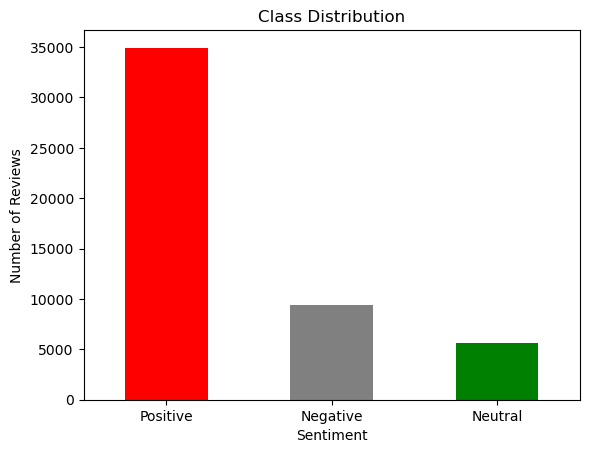

In [65]:
plt.Figure(figsize=(8,5))
sentiment_count.plot(kind='bar',color=["red","gray","green"])
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.ylabel("Number of Reviews")

### Interpretation: 
#### 1.Postive reviews are the majority class.
#### 2.Neutral reviews are the minority class.
#### 3.Negative reviews are the fewer.
#### 4.The dataset is imbalanced, Which explains why the Neutral Class is harder to learn for model 

In [66]:
!pip install wordcloud

In [67]:
from wordcloud import WordCloud

In [68]:
from wordcloud import STOPWORDS

custom_stopwords = STOPWORDS.union({
    "food",
    "restaurant",
    "place",
    "one",
    "go",
    "get",
    "would",
    "could",
    "really"
})

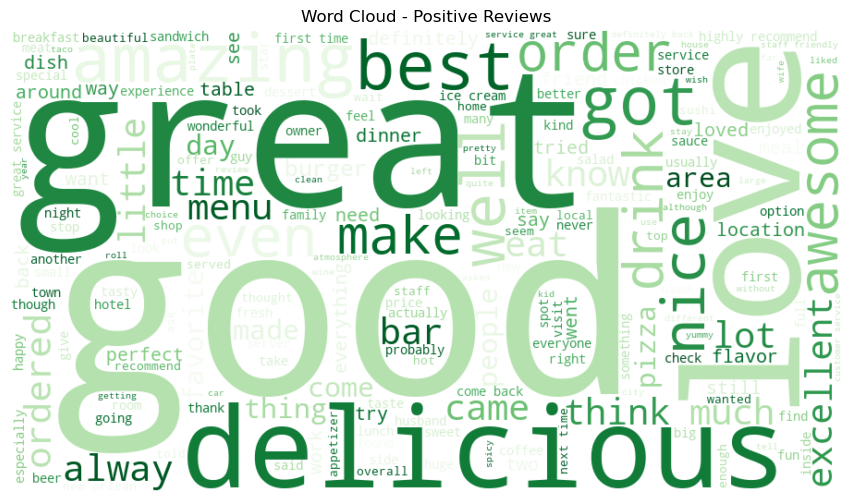

In [69]:
positive_text = " ".join(
    df[df["sentiment"]=="Positive"]["clean_text"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

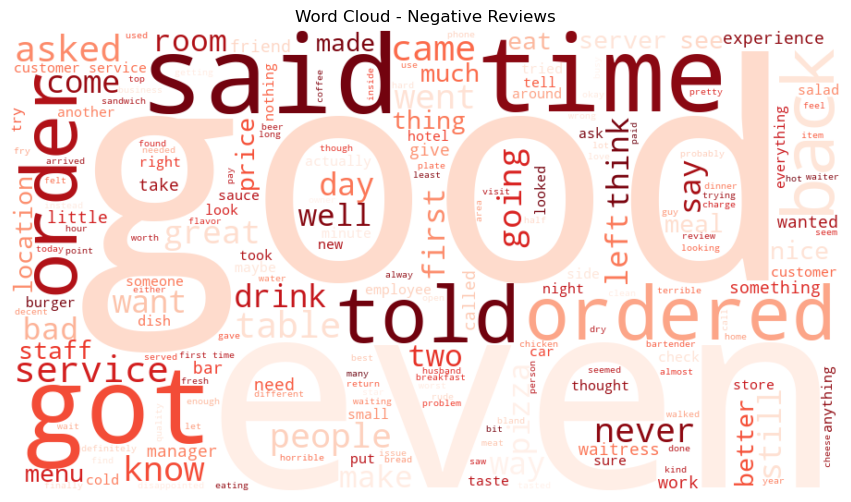

In [70]:
negative_text = " ".join(
    df[df["sentiment"]=="Negative"]["clean_text"]
)
wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Reds"
).generate(negative_text)


plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

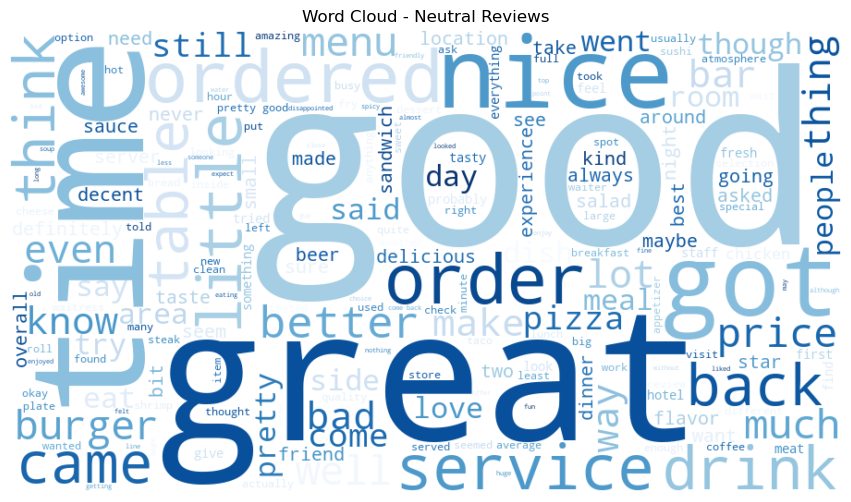

In [71]:
neutral_text = " ".join(
    df[df["sentiment"]=="Neutral"]["clean_text"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Blues"
).generate(neutral_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Neutral Reviews")
plt.show()

# Error analysis: show 5 examples the model misclassified and discuss why?

In [82]:
x_train, x_test, y_train, y_test, train_idx, test_idx = train_test_split(
    x,
    y,
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
predictions = pd.DataFrame({
    "Review": df.loc[test_idx, "text"],
    "Actual": y_test.values,
    "Predicted": y_pred
})

predictions.head()

,Review,Actual,Predicted
42652,We love Dr. Bradley and have generally receive...,Positive,Negative
35568,I love this car rental place! They allowed us ...,Positive,Positive
34676,A friend treated me to lunch at Mudbugs and I ...,Positive,Positive
4793,I like the atmosphere in the restaurant but th...,Negative,Negative
36028,This restaurant is our go to place to watch sp...,Positive,Positive


In [ ]:
misclassified = predictions[predictions["Actual"] != predictions["Predicted"]]
misclassified.head()

,Review,Actual,Predicted
42652,We love Dr. Bradley and have generally receive...,Positive,Negative
32051,The lunch and dinner menu is pretty standard M...,Neutral,Positive
897,"Cockroach in my room, wifi is slower than aol ...",Negative,Positive
38475,So I go to this cafe a lot and I gotta say tha...,Neutral,Positive
33614,Not at all authentic Vietnamese food and a lit...,Negative,Positive


In [90]:
for i, row in misclassified.head(5).iterrows():

    print("="*100)

    print("Review:")
    print(row["Review"])

    print("\nActual Sentiment:", row["Actual"])

    print("Predicted Sentiment:", row["Predicted"])

Review:
We love Dr. Bradley and have generally received very good care since RBVH took over the Cherry Hill location, However, I am very disappointed with them asking for a 60% deposit this morning for my dog's surgery before they would operate on her. We've been going to this location for the past 20 or so years (think Rosenberg days) and our chart is pages upon pages long with multiple dogs (at times 3 dogs under their care), 4 euthanized dogs, multiple hospital stays, thousands upon thousands of dollars in care, and they insulted me this morning by making me pay them $1,300 upfront before they would even operate on her. I can understand that for customers with limited or no history, but I don't walk out of that place with a bill generally less than $250 - $500 and to ask me for a deposit is shameless and insulting to me. Very bad business practice to ask for deposits from your best customers. Really is a shame that they care more about the dollar than your pet. It's all Red Bank big

##### 1st Review: In first review The model predicted Negative, whereas the actual sentiment was Positive. The review contains numerous strongly negative words such as disappointed, insulting, shameless, and bad business practice. Although the reviewer later updated the review and expressed satisfaction after the issue was resolved, the TF-IDF + SVM model treats words independently and cannot effectively capture the change in sentiment across the review. Consequently, the abundance of negative terms outweighed the positive conclusion, leading to a misclassification.

##### 2nd Review: The model predicted Positive, while the actual label was Neutral. The review contains several positive expressions such as "cooked perfectly," "very friendly," and "efficient," which strongly influenced the TF-IDF features. Although the reviewer also mentioned minor criticisms such as the smell of cleaning fluid and an unexciting menu, the overall wording was more positive than negative. Since the dataset labels are derived from star ratings rather than the textual sentiment alone, this represents a case of label inconsistency, where a 3-star (Neutral) rating accompanies predominantly positive language. Consequently, the model predicted Positive instead of Neutral.

##### 3rd Review: The review "Cockroach in my room, wifi is slower than AOL in 1996, private beach costs $10 a chair. I'll never come here again." was classified as Positive, although it is clearly Negative. The review relies on strong negative expressions, sarcasm, and the phrase "never come here again." A TF-IDF + SVM model treats words independently and cannot fully understand sarcasm, negation, or phrase-level meaning.

##### 4th Review: The review was labeled Neutral but predicted as Positive. Although the reviewer expressed disappointment with the quality of the kale salad, they also described themselves as a regular customer and praised the café's grilled cheese, stating that it was "always on point." These positive expressions received higher importance in the TF-IDF representation than the limited negative comments. Additionally, the review criticizes only one menu item rather than the overall dining experience. Since the dataset labels are derived from star ratings, the review was labeled Neutral despite containing predominantly positive language, resulting in a Positive prediction by the model.

##### 5th Review: The model classified this review as Positive, whereas the actual label was Negative. The review contains several positive expressions such as "chef is really friendly" and "good option for a quick, light lunch," which received high weights in the TF-IDF representation. However, the review's main opinion is negative, emphasizing that the restaurant is "not authentic" and explicitly stating "I don't recommend this place" for Vietnamese food. Because TF-IDF represents text primarily through individual words and has limited understanding of negation and contextual relationships, the positive vocabulary outweighed the overall negative recommendation, leading to a misclassification.

# Conclusion: which model performed best and what real-world application could this serve?

#### Logistic Regression
Achieved the highest accuracy (84.51%).
Performed well overall and provided stable predictions.
However, its recall and F1-score were lower than Linear SVM, indicating it missed more minority-class instances.

#### Multinomial Naïve Bayes
Achieved the highest precision (79.12%), meaning its positive predictions were usually correct.
However, it had the lowest recall and F1-score, making it less effective for handling the imbalanced dataset.

#### Linear Support Vector Machine
Achieved 84.23% accuracy, only slightly below Logistic Regression.
Obtained the highest Recall (69.96%) and highest F1-score (70.39%).
Since F1-score balances precision and recall, Linear SVM provides the most reliable overall performance for this sentiment classification task.

# Final Conclusion

Although Logistic Regression achieved the highest accuracy (84.51%), Linear SVM is the preferred model because it achieved the highest F1-score (70.39%) and highest recall (69.96%), indicating better performance across all sentiment classes, especially for minority classes such as Neutral and Negative.

For imbalanced multi-class sentiment classification, F1-score is generally a more informative metric than accuracy, making Linear SVM the best-performing model in this study.

# Real-World Applications

## The developed sentiment analysis model can be applied in various real-world scenarios, including:

##### Restaurant Review Analysis: Automatically classify customer reviews as Positive, Neutral, or Negative to monitor customer satisfaction.
##### Business Reputation Management: Help companies identify dissatisfied customers and respond promptly to negative feedback.
##### Product Review Analysis: Analyze customer opinions on e-commerce platforms such as Amazon or Flipkart.
##### Social Media Monitoring: Track public sentiment toward brands, products, or campaigns using reviews and social media posts.
##### Customer Support Prioritization: Automatically detect negative reviews and prioritize them for faster resolution.
##### Market Research: Understand customer preferences and identify areas for product or service improvement.
